## UTS PRAKTIKUM PENGOLAHAN CITRA DIGITAL
## Nama  : Anggia Putri Tesalonika Pane
## NIM   : 202431162
## Kelas : G

## Soal 1 Deteksi Warna

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

## Baca dan Menampilkan citra asli

In [11]:
img = cv2.imread('tulisan.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

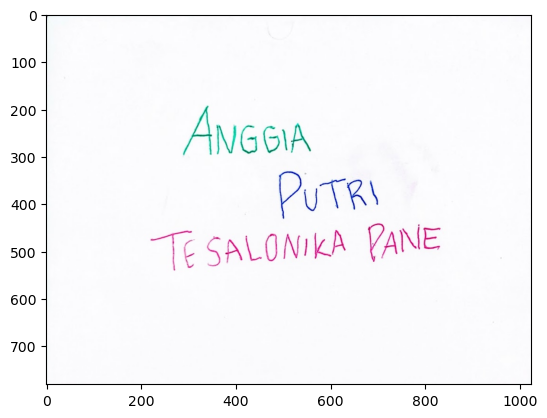

In [12]:
plt.imshow(img_rgb)

In [13]:
print(img.shape)

(781, 1024, 3)


## Deteksi Warna dari Biru, Merah, dan Hijau

In [14]:
r_diff = cv2.subtract(img_rgb[:, :, 0], cv2.max(img_rgb[:, :, 1], img_rgb[:, :, 2]))
g_diff = cv2.subtract(img_rgb[:, :, 1], cv2.max(img_rgb[:, :, 0], img_rgb[:, :, 2]))
b_diff = cv2.subtract(img_rgb[:, :, 2], cv2.max(img_rgb[:, :, 0], img_rgb[:, :, 1]))

In [15]:
_, r_mask = cv2.threshold(r_diff, 20, 255, cv2.THRESH_BINARY)
_, g_mask = cv2.threshold(g_diff, 20, 255, cv2.THRESH_BINARY)
_, b_mask = cv2.threshold(b_diff, 20, 255, cv2.THRESH_BINARY)

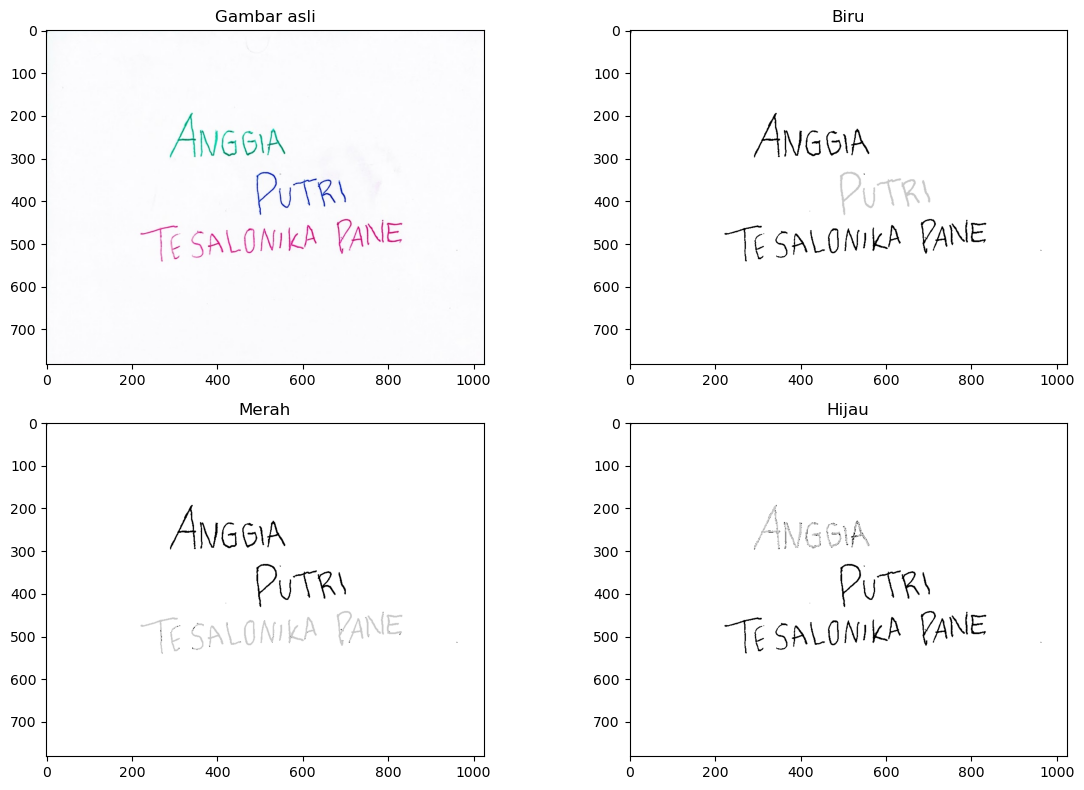

In [ ]:
def proc_res(t_mask, ori_img):
    out = np.full(ori_img.shape[:2], 255, dtype=np.uint8)

    gray = cv2.cvtColor(ori_img, cv2.COLOR_RGB2GRAY)
    _, txt_mask = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

    out[txt_mask > 0] = 0
    out[t_mask > 0] = 200

    return out

r_res = proc_res(r_mask, img_rgb)
g_res = proc_res(g_mask, img_rgb)
b_res = proc_res(b_mask, img_rgb)

ttl = ['Gambar asli', 'Biru', 'Merah', 'Hijau']
imgs = [img_rgb, b_res, r_res, g_res]

plt.figure(figsize=(12,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(imgs[i], cmap='gray' if i > 0 else None)
    plt.title(ttl[i])
    plt.axis('on')

plt.tight_layout()
plt.show()

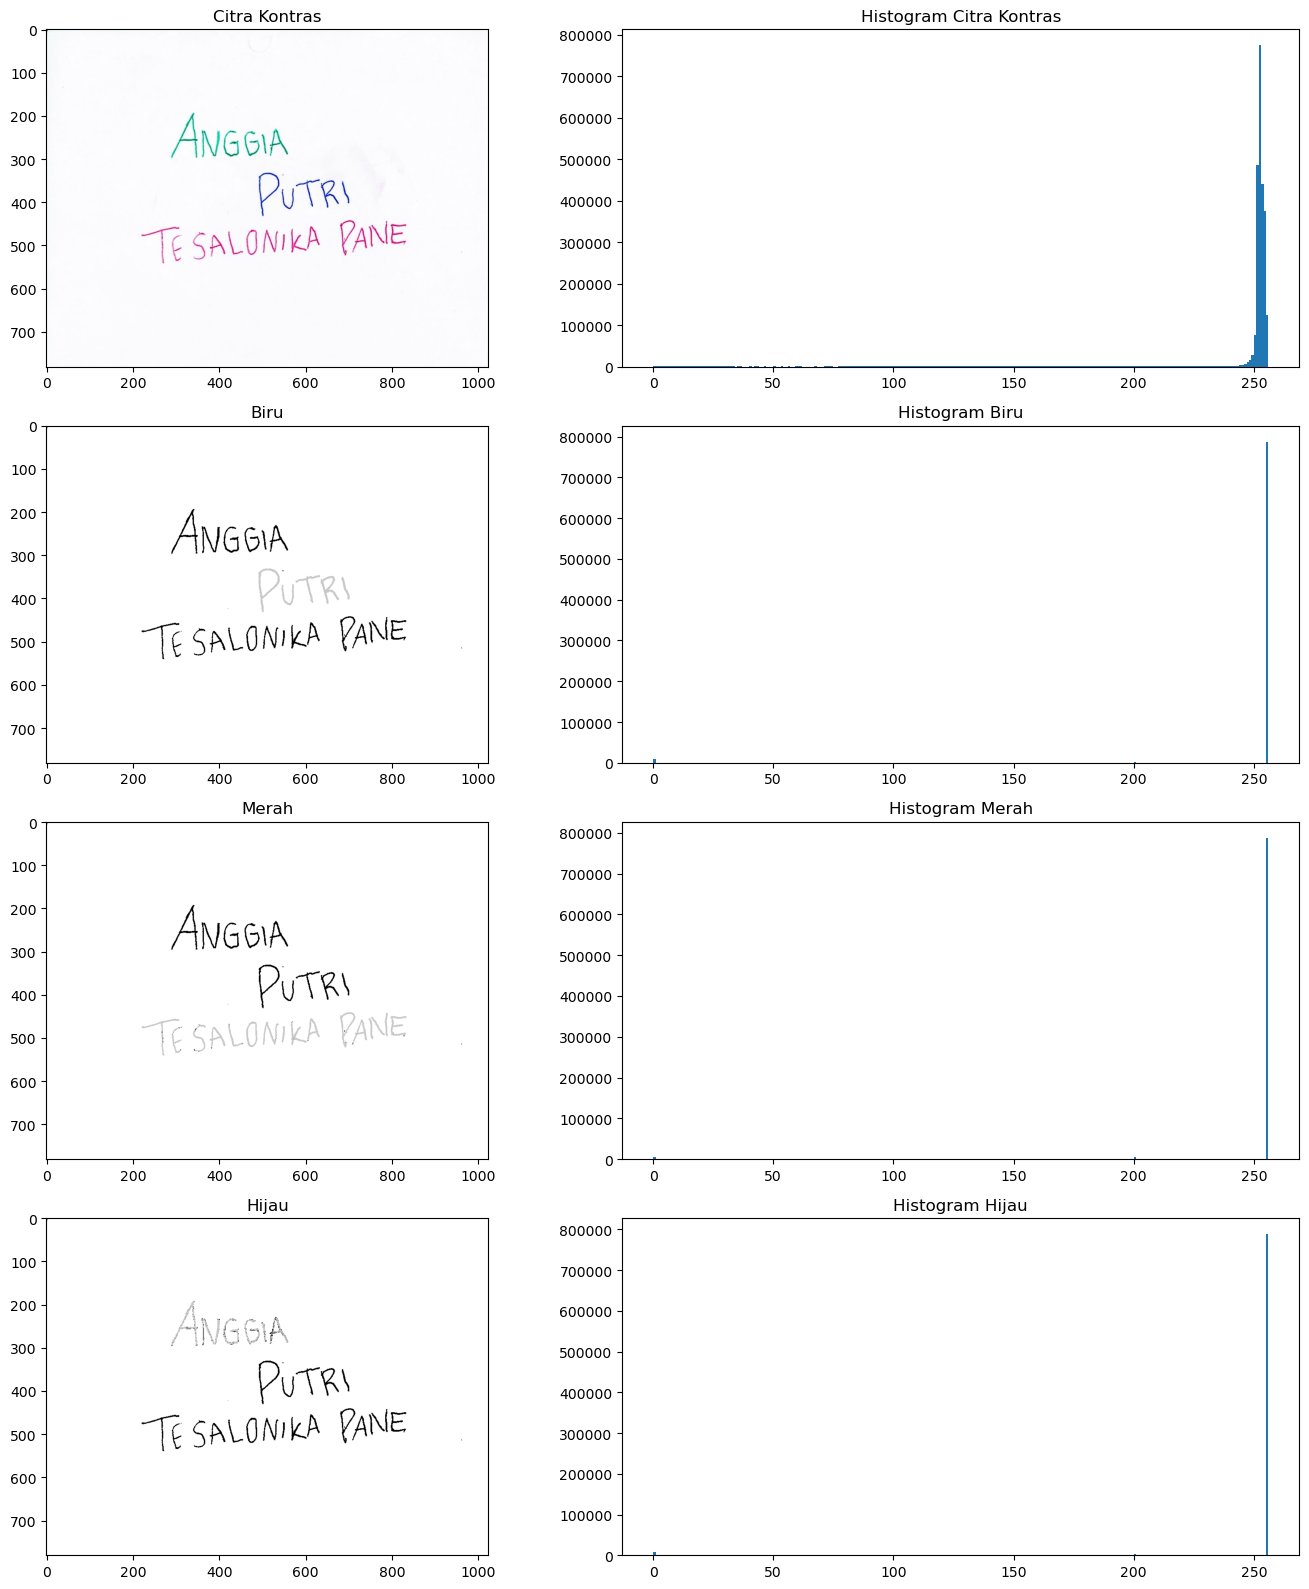

In [ ]:
r_res = r_res.astype(np.uint8)
g_res = g_res.astype(np.uint8)
b_res = b_res.astype(np.uint8)

fig, axs = plt.subplots(4, 2, figsize=(14, 16))

axs[0, 0].imshow(img_rgb)
axs[0, 0].set_title('Citra Kontras')

axs[0, 1].hist(img_rgb.ravel(), 256, range=[0, 256])
axs[0, 1].set_title('Histogram Citra Kontras')

axs[1, 0].imshow(b_res, cmap='gray')
axs[1, 0].set_title('Biru')

axs[1, 1].hist(b_res.ravel(), 256, range=[0, 256])
axs[1, 1].set_title('Histogram Biru')

axs[2, 0].imshow(r_res, cmap='gray')
axs[2, 0].set_title('Merah')

axs[2, 1].hist(r_res.ravel(), 256, range=[0, 256])
axs[2, 1].set_title('Histogram Merah')

axs[3, 0].imshow(g_res, cmap='gray')
axs[3, 0].set_title('Hijau')

axs[3, 1].hist(g_res.ravel(), 256, range=[0, 256])
axs[3, 1].set_title('Histogram Hijau')

plt.tight_layout()
plt.show()

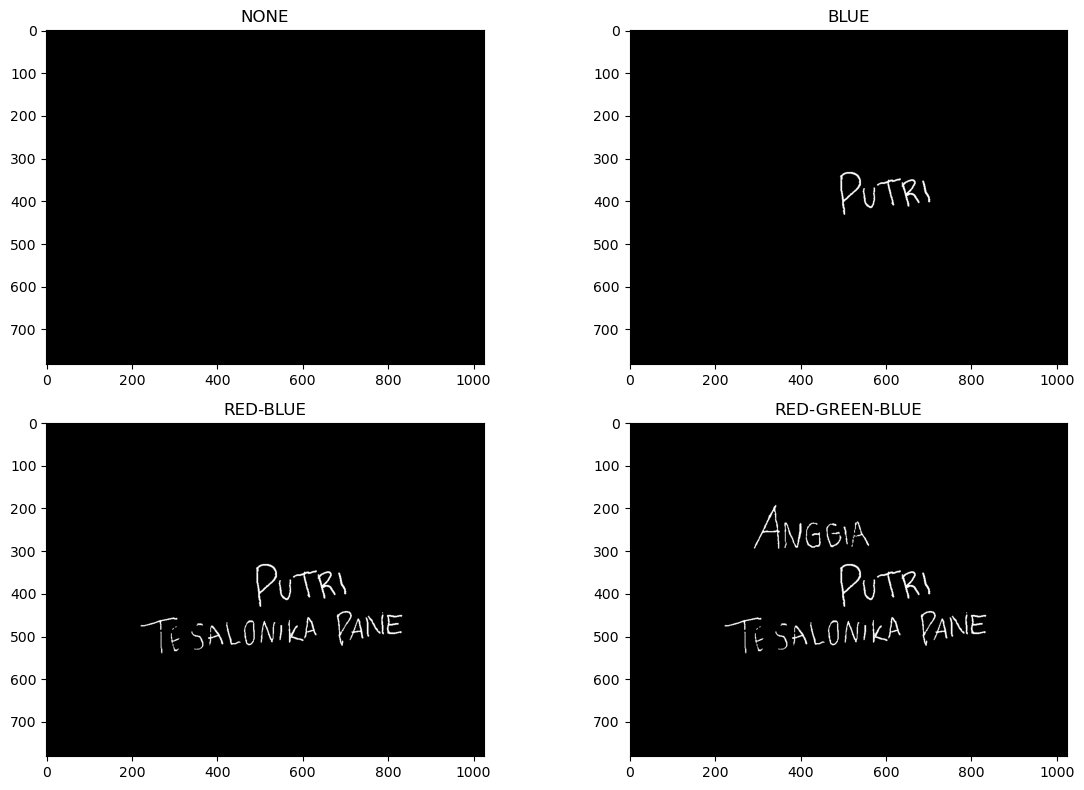

In [ ]:
r_ch = img_rgb[:, :, 0].astype(np.int16)
g_ch = img_rgb[:, :, 1].astype(np.int16)
b_ch = img_rgb[:, :, 2].astype(np.int16)

n_res = np.zeros(img_rgb.shape[:2], dtype=np.uint8)

b_mask = np.where(
    (b_ch > r_ch + 30) &
    (b_ch > g_ch + 30),
    255, 0
).astype(np.uint8)

r_mask = np.where(
    (r_ch > g_ch + 30) &
    (r_ch > b_ch + 30),
    255, 0
).astype(np.uint8)

rb_res = cv2.bitwise_or(r_mask, b_mask)

g_mask = np.where(
    (g_ch > r_ch + 20) &
    (g_ch > b_ch + 20),
    255, 0
).astype(np.uint8)

rgb_res = cv2.bitwise_or(rb_res, g_mask)

ttl = ['NONE', 'BLUE', 'RED-BLUE', 'RED-GREEN-BLUE']
imgs = [n_res, b_mask, rb_res, rgb_res]

plt.figure(figsize=(12, 8))

for i in range(4):
    plt.subplot(2, 2, i + 1)

    plt.imshow(imgs[i], cmap='gray')

    plt.title(ttl[i], fontsize=12)
    plt.axis('on')

plt.tight_layout()


plt.show()

## Soal 2 Perbaikan Foto backlight

## Menampilkan foto

In [24]:
img_p = cv2.imread('foto.jpeg')

In [26]:
image_photo_rgb = cv2.cvtColor(img_p, cv2.COLOR_BGR2RGB)

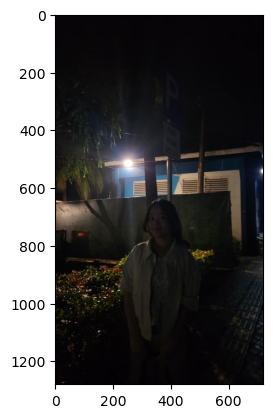

In [27]:
plt.imshow(image_photo_rgb)

## Konversi ke Grayscale

In [29]:
image_photo_gray = cv2.cvtColor(img_p, cv2.COLOR_BGR2GRAY)

## Tingkatkan Kecerahan

In [31]:
b_val = 50

img_bri = np.clip(
    image_photo_gray.astype(np.int32) + b_val,
    0,
    255
).astype(np.uint8)

In [32]:
g_val = 2.5

lut = np.array([
    ((i / 255.0) ** (1.0 / g_val)) * 255
    for i in range(256)
]).astype(np.uint8)


## Peningkatan Kontras

In [33]:
clahe = cv2.createCLAHE(
    clipLimit=4.5,
    tileGridSize=(8, 8)
)

image_contrast = clahe.apply(image_photo_gray)

## Penggabungan Kecerahan dan Kontras

In [38]:
image_bright_contrast = clahe.apply(img_bri)

## Hasil

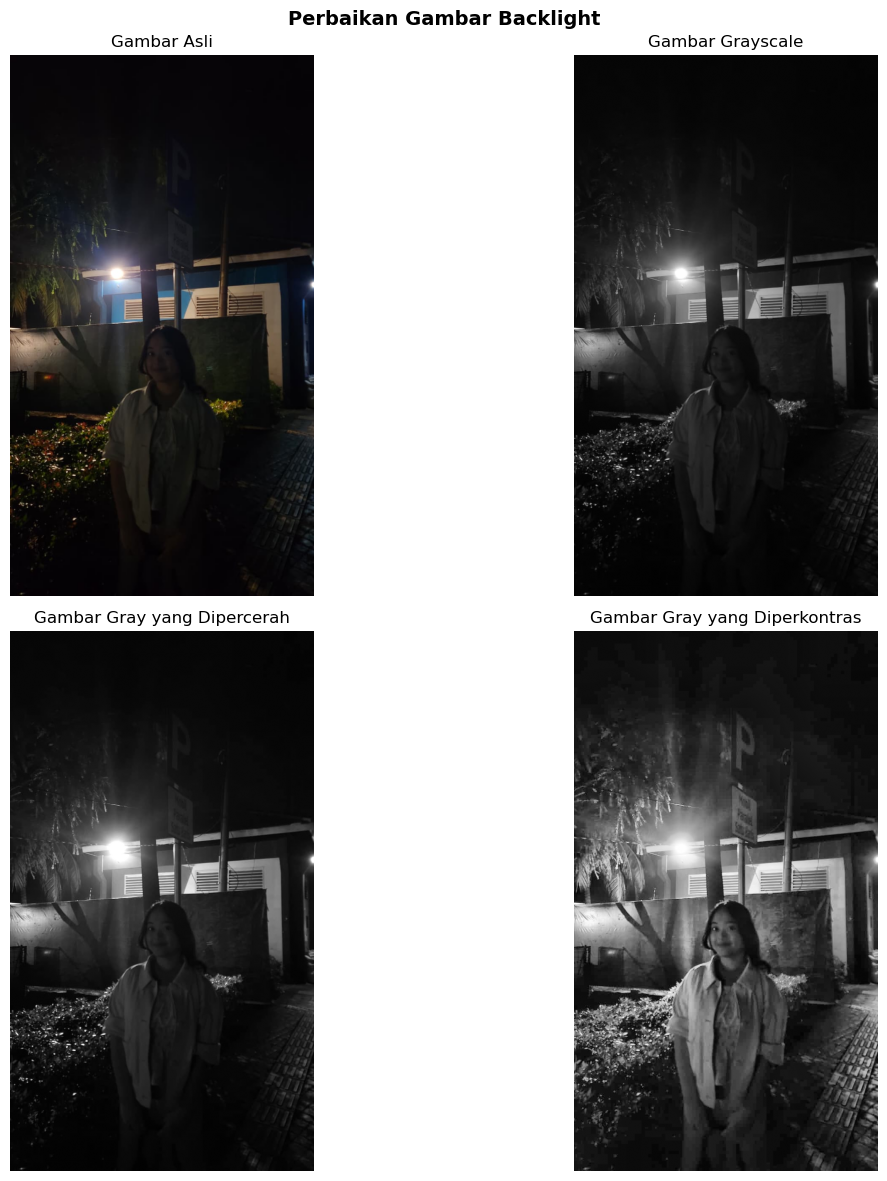

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].imshow(image_photo_rgb)
axes[0, 0].set_title('Gambar Asli', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(image_photo_gray, cmap='gray')
axes[0, 1].set_title('Gambar Grayscale', fontsize=12)
axes[0, 1].axis('off')

axes[1, 0].imshow(img_bri, cmap='gray')
axes[1, 0].set_title('Gambar Gray yang Dipercerah', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(image_contrast, cmap='gray')
axes[1, 1].set_title('Gambar Gray yang Diperkontras', fontsize=12)
axes[1, 1].axis('off')

plt.suptitle('Perbaikan Gambar Backlight', fontsize=14, fontweight='bold')

plt.tight_layout()

plt.show()

## Tampilkan hasil akhir

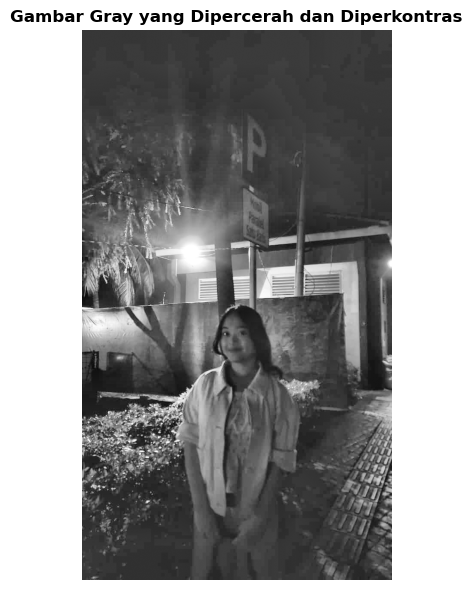

In [41]:
plt.figure(figsize=(7, 6))
plt.imshow(image_bright_contrast, cmap='gray')
plt.title('Gambar Gray yang Dipercerah dan Diperkontras', fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()